# Stag GAN Inference

This notebook demonstrates inference with StagGAN, a STAG model pre-trained to generate SONAR sentence embeddings using a GAN training. 

We'll load the trained model, generate samples and convert the generated embeddings to text. 

In [1]:
import sys
import os

root_dir = "/home/hukami/Workspace/Gen-AI-Lab"
sys.path.append(root_dir)

import torch
import torch.nn.functional as F
from sonar.inference_pipelines.text import (
    TextToEmbeddingModelPipeline,
    EmbeddingToTextModelPipeline,
)
from lit.models.stag_gan import StagGAN
import numpy as np
import yaml
import glob
import pyarrow.parquet as pq

# Check device availability and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Initialize SONAR Models

In [2]:
# Embeddings back to text
vec2text = EmbeddingToTextModelPipeline(
    decoder="text_sonar_basic_decoder", 
    tokenizer="text_sonar_basic_encoder"
)

#### Initialize StagCM Model

In [3]:
experiement = "0"
checkpoint_dir = f"lightning_logs/stag_gan_pretraining/version_{experiement}/checkpoints/"
checkpoint_file = "periodic-epoch=0-step=8000.ckpt"

model = StagGAN.load_from_checkpoint(
    os.path.join(
        root_dir,
        checkpoint_dir,
        checkpoint_file,
    )
)
model = model.to(device)

generator = model.generator
generator.eval()


StagGenerator(
  (mapping): MappingNetwork(
    (mapping): Sequential(
      (0): Linear(in_features=512, out_features=1024, bias=True)
      (1): LeakyReLU(negative_slope=0.2)
      (2): Linear(in_features=1024, out_features=1024, bias=True)
      (3): LeakyReLU(negative_slope=0.2)
      (4): Linear(in_features=1024, out_features=1024, bias=True)
      (5): LeakyReLU(negative_slope=0.2)
      (6): Linear(in_features=1024, out_features=1024, bias=True)
      (7): LeakyReLU(negative_slope=0.2)
      (8): Linear(in_features=1024, out_features=1024, bias=True)
      (9): LeakyReLU(negative_slope=0.2)
      (10): Linear(in_features=1024, out_features=1024, bias=True)
      (11): LeakyReLU(negative_slope=0.2)
      (12): Linear(in_features=1024, out_features=1024, bias=True)
      (13): LeakyReLU(negative_slope=0.2)
      (14): Linear(in_features=1024, out_features=1024, bias=True)
      (15): LeakyReLU(negative_slope=0.2)
    )
  )
  (topic_projection): Linear(in_features=1024, out_feature

In [4]:
# Generate latent noise
num_samples = 10
z = torch.randn(num_samples, model.hparams.z_dim).to(device)

In [5]:
# load topic embeddings
data_path = os.path.join(root_dir, "data/wiki40b_sonar_sentences/flat/*.parquet")
parquet_files = glob.glob(data_path)

if not parquet_files:
    raise FileNotFoundError(f"No parquet files found in {os.path.dirname(data_path)}")

table = pq.read_table(parquet_files[0])
# All sentences in a file share the same article embedding, so we take the first one.
article_embedding_list = table.column("article_embedding").to_pylist()[0]
topic_embedding = torch.tensor(article_embedding_list, dtype=torch.float).to(device)

topic_embedding = topic_embedding.unsqueeze(0).repeat(num_samples, 1)

with torch.no_grad():
    generated_embeddings, _ = generator(z, topic_embedding)

In [6]:
model.eval()
model.cpu()
torch.cuda.empty_cache()

# load vec2text model
vec2text = EmbeddingToTextModelPipeline(
    decoder="text_sonar_basic_decoder", 
    tokenizer="text_sonar_basic_encoder",
    device=device
)

generated_texts = vec2text.predict(
    generated_embeddings, target_lang="eng_Latn"
)

In [13]:
generated_texts

['countertountertountertontontontontontontontontontontontontontontontontonton',
 'gainstinstinstinstinstanttontontontontontontontontontontontontontontonton',
 'gainstinstinstinstinstanttontontontontontontontontontontontontonton',
 'gainstinstinstinstinstanttontontontontontontontontontontontontontontonton',
 'gainstinstinstinstinstanttontontontontontontontontontontontontonton',
 'gainstinstinstinstanttontontontontontontontontontontontontontontonton',
 'gainstinstinstinstinstanttontontontontontontontontontontontontontonton',
 '" " " " " " " " - or lawy- or lawy- or lawy',
 'gainstinstinstinstinstanttontontontontontontontontontontontontontontonton',
 'countertountertontontontontontontontontontontontontontontonton']

In [27]:
generated_embeddings

tensor([[ 0.0668,  0.0112, -0.0540,  ..., -0.1153,  0.0041, -0.0300],
        [ 0.0668,  0.0112, -0.0540,  ..., -0.1153,  0.0041, -0.0300],
        [ 0.0668,  0.0112, -0.0540,  ..., -0.1153,  0.0041, -0.0300],
        ...,
        [ 0.0668,  0.0112, -0.0540,  ..., -0.1153,  0.0041, -0.0300],
        [ 0.0668,  0.0112, -0.0540,  ..., -0.1153,  0.0041, -0.0300],
        [ 0.0668,  0.0112, -0.0540,  ..., -0.1153,  0.0041, -0.0300]],
       device='cuda:0')

: 

In [39]:
# --- Outlier Investigation with Real Data ---
from lit.data.sonar_parquet_datamodule import Wiki40bDataModule
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize the DataModule to load a real data batch
# We set return_article_embedding=True to get the topic vectors
datamodule = Wiki40bDataModule(
    data_dir=os.path.join(root_dir, "data/wiki40b_sonar_sentences"),
    batch_size=4,  # Load 4 sequences
    sequence_length=256, # Each with 256 sentences
    num_workers=0, # Simpler for interactive use
    return_article_embedding=True,
    shuffle_files=True,
    shuffle_sentences=True,
)

# 2. Setup the datamodule and get the dataloader
datamodule.setup()
train_loader = datamodule.train_dataloader()

try:
    # 3. Load one batch of data
    batch = next(iter(train_loader))
    sentence_embeddings, article_embeddings = batch

    # Flatten the batch as done in the training script
    real_embeddings = sentence_embeddings.view(-1, model.hparams.model_dim).to(device)
    topic_embeddings = article_embeddings.view(-1, model.hparams.model_dim).to(device)


except StopIteration:
    print("Could not load a batch from the dataloader. Is the dataset empty or the path correct?")


--- Cosine Similarity Analysis (Real Data Batch) ---
Loaded 1024 sentence-topic pairs.
Mean Cosine Similarity: 0.4545
Std Dev of Similarity: 0.1518
Outlier Threshold (Mean - 2.7*Std): 0.0446
Found 1 outliers in this batch.


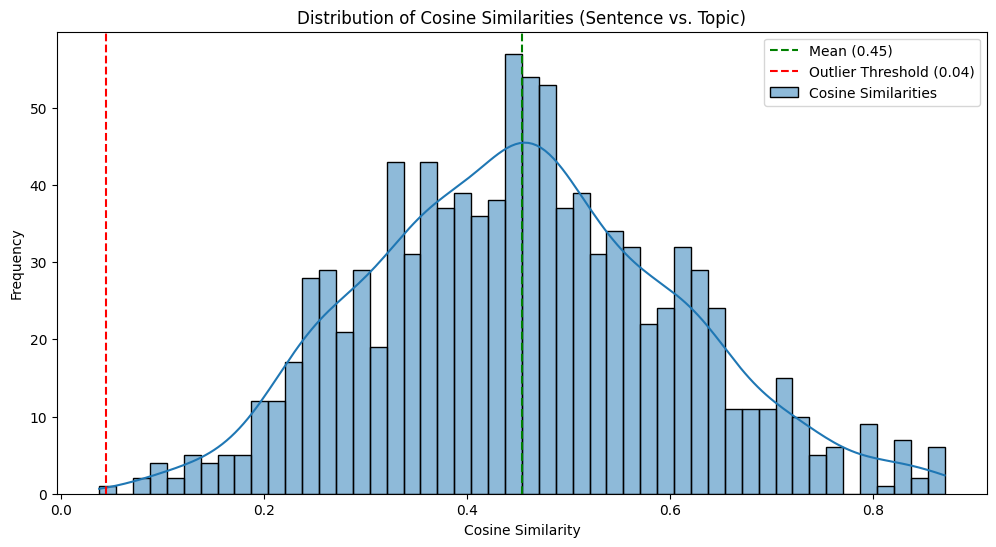

In [42]:
# 4. Calculate Cosine Similarity between sentence and topic
# A value of 1 means perfectly aligned, -1 means opposite.
cosine_sim = F.cosine_similarity(real_embeddings, topic_embeddings, dim=1)

# 5. Define outliers based on a statistical threshold
# We'll consider anything more than 2 standard deviations below the mean as an outlier.
factor = 2.7
mean_sim = cosine_sim.mean()
std_sim = cosine_sim.std()
outlier_threshold = mean_sim - factor * std_sim

# A lower cosine similarity score means less coherence (more likely an outlier)
outlier_mask = cosine_sim < outlier_threshold

print(f"--- Cosine Similarity Analysis (Real Data Batch) ---")
print(f"Loaded {real_embeddings.shape[0]} sentence-topic pairs.")
print(f"Mean Cosine Similarity: {mean_sim.item():.4f}")
print(f"Std Dev of Similarity: {std_sim.item():.4f}")
print(f"Outlier Threshold (Mean - {factor}*Std): {outlier_threshold.item():.4f}")
print(f"Found {outlier_mask.sum().item()} outliers in this batch.")

# 6. Plot the distribution
plt.figure(figsize=(12, 6))
sns.histplot(cosine_sim.cpu().numpy(), bins=50, kde=True, label="Cosine Similarities")
plt.axvline(mean_sim.cpu().numpy(), color='green', linestyle='--', label=f'Mean ({mean_sim.item():.2f})')
plt.axvline(outlier_threshold.cpu().numpy(), color='red', linestyle='--', label=f'Outlier Threshold ({outlier_threshold.item():.2f})')
plt.title("Distribution of Cosine Similarities (Sentence vs. Topic)")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.legend()
plt.show()


--- Mahalanobis Distance Analysis (Real Data Batch) ---
Loaded 1024 sentence-topic pairs.
Mean Mahalanobis Distance: 18.0131
Std Dev of Distance: 3.6239
Outlier Threshold (Mean + 3*Std): 28.8847
Found 8 outliers in this batch.


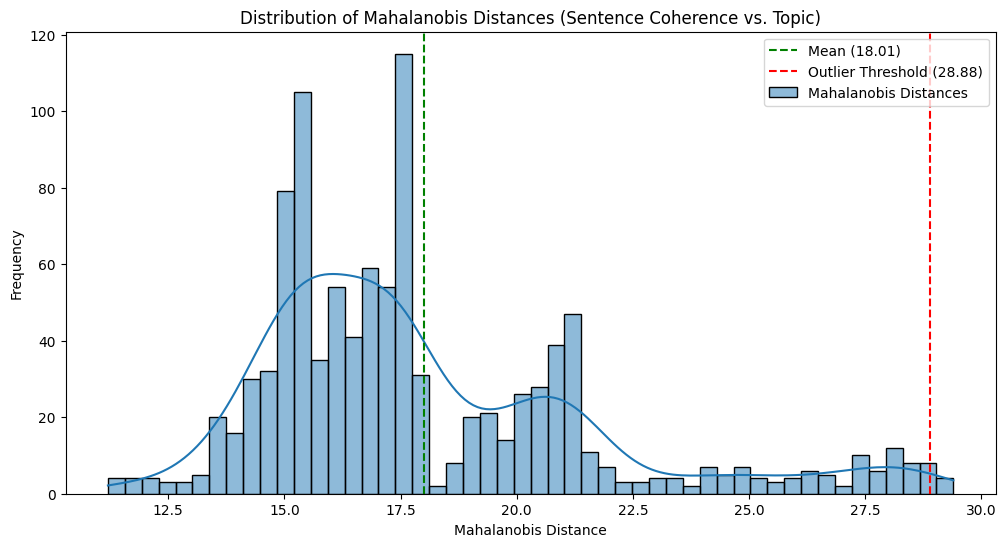

In [45]:

# 1. Calculate the coherence signal
coherence_signal = real_embeddings - topic_embeddings
num_samples, dim = coherence_signal.shape

# 2. Calculate the mean and covariance matrix of the signal
mean_vec = torch.mean(coherence_signal, dim=0)
cov_matrix = torch.cov(coherence_signal.T)

# 3. Calculate the inverse covariance (precision) matrix
# Add a small regularization term (epsilon) for numerical stability
epsilon = 1e-5
inv_cov_matrix = torch.inverse(cov_matrix + epsilon * torch.eye(dim, device=device))

# 4. Calculate the Mahalanobis distance for each sample
# d^2 = (x - mu)^T * Sigma^-1 * (x - mu)
diff = coherence_signal - mean_vec
mahalanobis_dist_sq = torch.diag(torch.mm(torch.mm(diff, inv_cov_matrix), diff.T))
mahalanobis_dist = torch.sqrt(mahalanobis_dist_sq).to(torch.float32)

# 5. Define outliers based on a statistical threshold
# For Mahalanobis distance, a common heuristic is to use a threshold
# based on the mean and standard deviation of the distances themselves.
dist_mean = mahalanobis_dist.mean()
dist_std = mahalanobis_dist.std()
outlier_threshold = dist_mean + 3 * dist_std # 3 standard deviations from the mean

outlier_mask = mahalanobis_dist > outlier_threshold

print(f"--- Mahalanobis Distance Analysis (Real Data Batch) ---")
print(f"Loaded {num_samples} sentence-topic pairs.")
print(f"Mean Mahalanobis Distance: {dist_mean.item():.4f}")
print(f"Std Dev of Distance: {dist_std.item():.4f}")
print(f"Outlier Threshold (Mean + 3*Std): {outlier_threshold.item():.4f}")
print(f"Found {outlier_mask.sum().item()} outliers in this batch.")

# 6. Plot the distribution
plt.figure(figsize=(12, 6))
sns.histplot(mahalanobis_dist.cpu().numpy(), bins=50, kde=True, label="Mahalanobis Distances")
plt.axvline(dist_mean.cpu().numpy(), color='green', linestyle='--', label=f'Mean ({dist_mean.item():.2f})')
plt.axvline(outlier_threshold.cpu().numpy(), color='red', linestyle='--', label=f'Outlier Threshold ({outlier_threshold.item():.2f})')
plt.title("Distribution of Mahalanobis Distances (Sentence Coherence vs. Topic)")
plt.xlabel("Mahalanobis Distance")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [46]:

# 7. Inspect the text of outliers vs. non-outliers
# Ensure models are on the correct device for prediction
vec2text = vec2text.to(device)
outlier_embeddings = real_embeddings[outlier_mask]
non_outlier_embeddings = real_embeddings[~outlier_mask]

max_texts_to_show = 10

if outlier_embeddings.shape[0] > 0:
    outlier_texts = vec2text.predict(list(outlier_embeddings[:max_texts_to_show]), target_lang="eng_Latn")
    print(f"\\n--- Outlier Texts (Low Similarity) ---")
    for text in outlier_texts:
        print(f"- {text}")

if non_outlier_embeddings.shape[0] > 0:
    non_outlier_texts = vec2text.predict(list(non_outlier_embeddings[:max_texts_to_show]), target_lang="eng_Latn")
    print(f"\\n--- Non-Outlier Texts (High Similarity) ---")
    for text in non_outlier_texts:
        print(f"- {text}")
        
# Free up memory
vec2text.to("cpu")
torch.cuda.empty_cache()

\n--- Outlier Texts (Low Similarity) ---
- The sense of involvement and fun is carried over in the press cuttings; the journalists were most pleased by the fact that the show was opened by Robby the Robot, star of the science fiction film Forbidden Planet and easier to book than Marilyn Monroe.
- Highmore, Ben. "Rough Poetry: Patio and Pavilion Revisited. Oxford Art Journal 29, No. 2 (June 2006): 269-290.
- Along with leaving with Vandenburgh to go to WGDJ was the Live from the Capitol report with Fred Dicker and a weekly interview show with Albany Mayor Jerry Jensen.
- The band went on both headlining tours and supporting tours with American bands Alter Bridge, Mammoth WVH and Pistols at Dawn for the month of January and most of February.
- Hong Kong film historian Bey Logan says Lewis was the original choice for Bruce Lee's villain in Colt in The Way of the Dragon, but that Lewis and Lee had a falling out or Lewis had a scheduling conflict, and so Chuck Norris was cast instead.
- C